In [1]:
"""
Simulación del proceso de clasificación de audio del paper "Sound Classification Using Python".
Este script replica la metodología descrita, utilizando librerías como Librosa para la
extracción de características.

Referencia: ITM Web of Conferences 40, 03024 (2021)
Dataset: https://github.com/karolpiczak/ESC-50?tab=readme-ov-file
"""

'\nSimulación del proceso de clasificación de audio del paper "Sound Classification Using Python".\nEste script replica la metodología descrita, utilizando librerías como Librosa para la\nextracción de características.\n\nReferencia: ITM Web of Conferences 40, 03024 (2021)\nDataset: https://github.com/karolpiczak/ESC-50?tab=readme-ov-file\n'

In [2]:
!pip install --upgrade librosa matplotlib

In [11]:
# ---------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# Se importan las mismas librerías mencionadas en la sección 5.1 del paper.
# ---------------------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pickle

In [4]:
# ---------------------------------------------------------------------------
# 2. CARGA Y PRE-PROCESAMIENTO DE DATOS (SIMULADO)
# El paper utiliza un archivo "esc50.csv" y 10 clases.
# Aquí simulamos ese proceso creando un DataFrame y archivos de audio sintéticos por medio de tonos puros.
# Una vez simulado los tonos puros, vamos a cargar 5 sonidos de 10 clases del dataset.
# ---------------------------------------------------------------------------

# Creación de un directorio para los archivos de audio de simulación
if not os.path.exists('audio_simulation'):
    os.makedirs('audio_simulation')

# Función para generar un archivo de audio WAV sintético (tono puro)
def crear_audio_sintetico(filename, freq, duration=2, sr=22050):
    t = np.linspace(0., duration, int(sr * duration))
    amplitude = np.iinfo(np.int16).max * 0.5
    data = amplitude * np.sin(2. * np.pi * freq * t)
    # Usamos librosa para escribir el archivo, aunque soundfile es más común para esto.
    # Aquí lo mantenemos por consistencia con la librería principal del paper.
    # Nota: Librosa 0.10+ eliminó `librosa.output.write_wav`. Usamos `soundfile` que es una dependencia de librosa.
    import soundfile as sf
    sf.write(filename, data.astype(np.int16), sr)

# Simulación de tonos y creación de un archivo por clase
num_archivos_por_clase = 1
frecuencias_banda_octava = {
    'Tono_125Hz': 125,
    'Tono_250Hz': 250,
    'Tono_500Hz': 500,
    'Tono_1000Hz': 1000,
    'Tono_2000Hz': 2000,
    'Tono_4000Hz': 4000,
    'Tono_8000Hz': 8000,
    'Tono_16000Hz': 16000
}

metadata_simulada = []
print("Generando archivos de audio sintéticos para la simulación...")
for clase, freq in frecuencias_banda_octava.items():
    for i in range(num_archivos_por_clase):
        file_name = f"audio_simulation/{clase}_{i}.wav"
        # Añadimos una pequeña variación de frecuencia para que no sean idénticos
        crear_audio_sintetico(file_name, freq + np.random.uniform(-20, 20))
        metadata_simulada.append({'filename': file_name, 'esc10': clase})

# Creación del DataFrame de pandas, como se menciona en el paper
df = pd.DataFrame(metadata_simulada)
print("DataFrame simulado creado con éxito:")
print(df.head())
print(f"\nNúmero total de archivos: {len(df)}")
print(f"Número de clases: {df['esc10'].nunique()}")

Generando archivos de audio sintéticos para la simulación...
DataFrame simulado creado con éxito:
                             filename        esc10
0   audio_simulation/Tono_125Hz_0.wav   Tono_125Hz
1   audio_simulation/Tono_250Hz_0.wav   Tono_250Hz
2   audio_simulation/Tono_500Hz_0.wav   Tono_500Hz
3  audio_simulation/Tono_1000Hz_0.wav  Tono_1000Hz
4  audio_simulation/Tono_2000Hz_0.wav  Tono_2000Hz

Número total de archivos: 8
Número de clases: 8


Revisar el path Archivos/content/audio-simulation


Visualizando muestra: audio_simulation/Tono_500Hz_0.wav


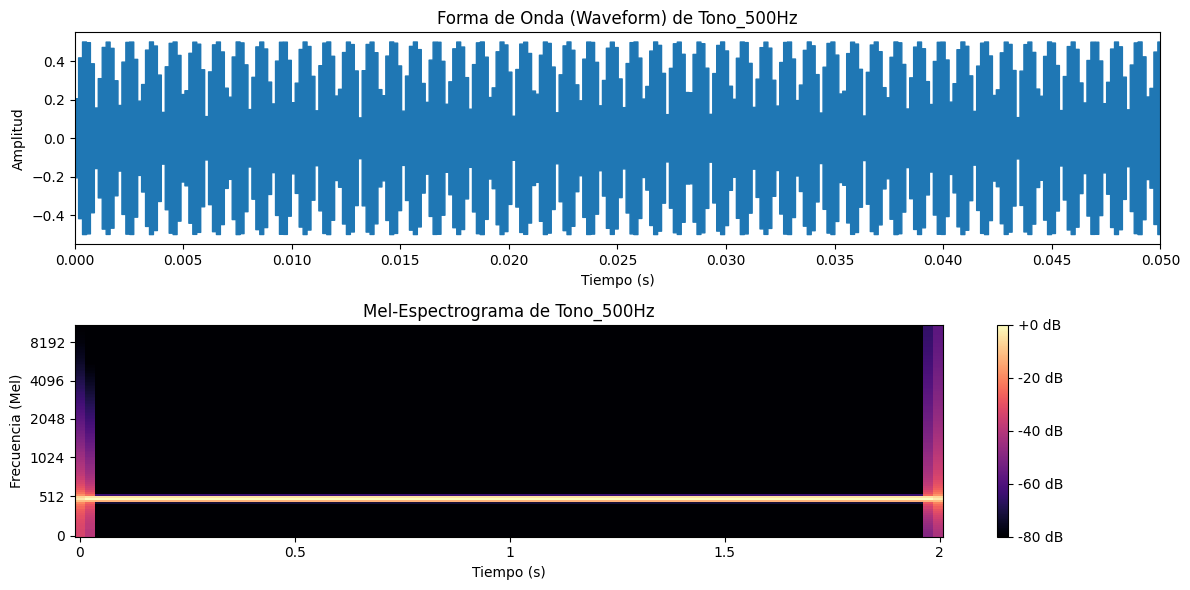

In [6]:
# ---------------------------------------------------------------------------
# 3. VISUALIZACIÓN DE UNA MUESTRA DE AUDIO
# El paper visualiza la forma de onda y el espectrograma (Figuras 2 y 3).
# ---------------------------------------------------------------------------

# Tomamos una muestra para visualizar, por ejemplo, el primer "Tono_440Hz"
sample_file = df['filename'][2]
y, sr = librosa.load(sample_file)

print(f"\nVisualizando muestra: {sample_file}")

# Calcular mel-espectrograma
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr)
mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

# Figura para visualización
plt.figure(figsize=(12, 6))

# Subplot 1: Forma de onda (Audio Waveform)
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title(f'Forma de Onda (Waveform) de {df["esc10"][2]}')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 0.05)

# Subplot 2: Mel-Espectrograma
plt.subplot(2, 1, 2)
librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Espectrograma de {df["esc10"][2]}')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Mel)")

plt.tight_layout()
plt.show()

In [7]:
# ---------------------------------------------------------------------------
# 2B. CARGA Y PRE-PROCESAMIENTO DE DATOS USANDO "esc50.csv"
# Aquí simulamos ese proceso creando un DataFrame y archivos de audio sintéticos por medio de tonos puros.
# Se cargan 5 sonidos de 10 clases del dataset, previamente seleccionado.
# ---------------------------------------------------------------------------

from google.colab import files

# Create the base directory where files will be saved
upload_dir = "real_audio_dataset"
os.makedirs(upload_dir, exist_ok=True)

# Upload files (you can select multiple)
uploaded = files.upload()

# Move uploaded files into the dataset directory
for fname in uploaded.keys():
    os.rename(fname, os.path.join(upload_dir, fname))

Saving Trueno_5.wav to Trueno_5.wav
Saving Trueno_4.wav to Trueno_4.wav
Saving Trueno_3.wav to Trueno_3.wav
Saving Trueno_2.wav to Trueno_2.wav
Saving Trueno_1.wav to Trueno_1.wav
Saving Gallo_5.wav to Gallo_5.wav
Saving Gallo_4.wav to Gallo_4.wav
Saving Gallo_3.wav to Gallo_3.wav
Saving Gallo_2.wav to Gallo_2.wav
Saving Gallo_1.wav to Gallo_1.wav
Saving Cerdo_5.wav to Cerdo_5.wav
Saving Cerdo_4.wav to Cerdo_4.wav
Saving Cerdo_3.wav to Cerdo_3.wav
Saving Cerdo_2.wav to Cerdo_2.wav
Saving Cerdo_1.wav to Cerdo_1.wav
Saving Gato_5.wav to Gato_5.wav
Saving Gato_4.wav to Gato_4.wav
Saving Gato_3.wav to Gato_3.wav
Saving Gato_2.wav to Gato_2.wav
Saving Gato_1.wav to Gato_1.wav
Saving Estornudo_5.wav to Estornudo_5.wav
Saving Estornudo_4.wav to Estornudo_4.wav
Saving Estornudo_3.wav to Estornudo_3.wav
Saving Estornudo_2.wav to Estornudo_2.wav
Saving Estornudo_1.wav to Estornudo_1.wav
Saving Perro_5.wav to Perro_5.wav
Saving Perro_4.wav to Perro_4.wav
Saving Perro_3.wav to Perro_3.wav
Saving P

In [8]:
# Ruta al directorio donde estan los archivos
upload_dir = "real_audio_dataset"

# Lista para guardar la metadata
metadata_real = []

# Iteramos sobre los archivos en el directorio
for fname in os.listdir(upload_dir):
    if fname.endswith(".wav"):
        # Extraemos el nombre de clase del nombre del archivo, antes del primer "_"
        clase = fname.split("_")[0]
        full_path = os.path.join(upload_dir, fname)
        metadata_real.append({'filename': full_path, 'esc10': clase})

# Creación del DataFrame
df_real = pd.DataFrame(metadata_real)

# Visualización de resultados
print("DataFrame de audio real creado con éxito:")
print(df_real.head())
print(f"\nNúmero total de archivos: {len(df_real)}")
print(f"Número de clases: {df_real['esc10'].nunique()}")

DataFrame de audio real creado con éxito:
                                    filename   esc10
0            real_audio_dataset/Trueno_5.wav  Trueno
1              real_audio_dataset/Gota_1.wav    Gota
2  real_audio_dataset/Leña_Quemandose_4.wav   Leña
3             real_audio_dataset/Perro_2.wav   Perro
4              real_audio_dataset/Gato_1.wav    Gato

Número total de archivos: 50
Número de clases: 10



Visualizando muestra: real_audio_dataset/Trueno_5.wav


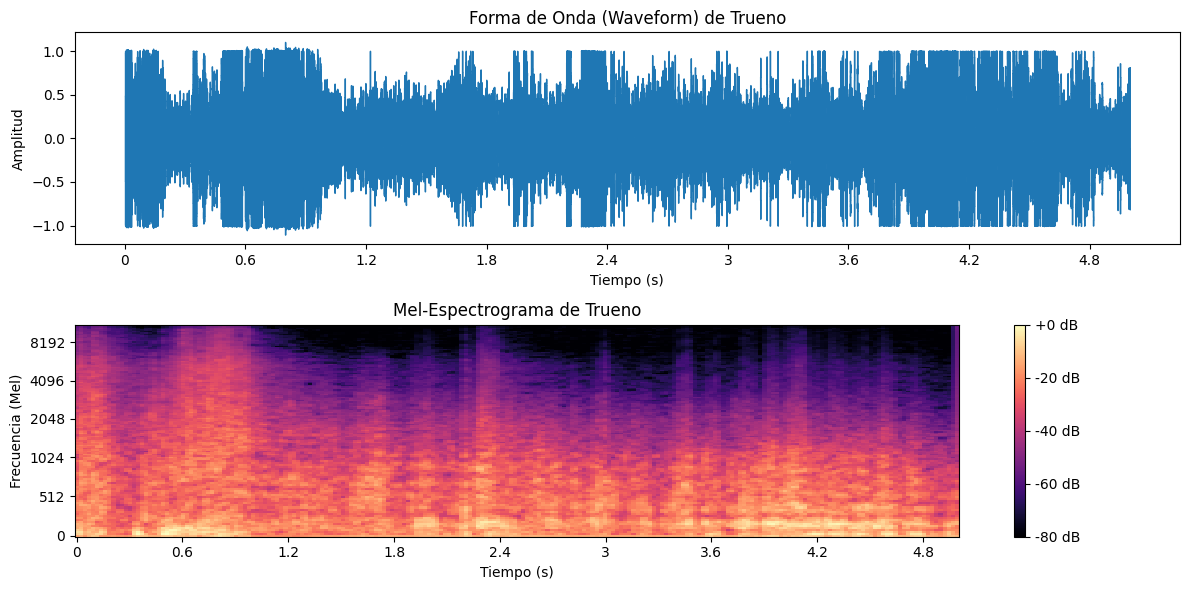

In [9]:
# ---------------------------------------------------------------------------
# 3B. VISUALIZACIÓN DE UNA MUESTRA DE AUDIO REAL
# Visualizamos la forma de onda y el mel-espectrograma del primer archivo real.
# ---------------------------------------------------------------------------

# Tomamos una muestra del nuevo DataFrame (df_real)
sample_file_real = df_real['filename'][0]
y_real, sr_real = librosa.load(sample_file_real)

print(f"\nVisualizando muestra: {sample_file_real}")

# Calcular mel-espectrograma
mel_spect_real = librosa.feature.melspectrogram(y=y_real, sr=sr_real)
mel_spect_db_real = librosa.power_to_db(mel_spect_real, ref=np.max)

# Figura para visualización
plt.figure(figsize=(12, 6))

# Subplot 1: Forma de onda
plt.subplot(2, 1, 1)
librosa.display.waveshow(y_real, sr=sr_real)
plt.title(f'Forma de Onda (Waveform) de {df_real["esc10"][0]}')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

# Subplot 2: Mel-Espectrograma
plt.subplot(2, 1, 2)
librosa.display.specshow(mel_spect_db_real, sr=sr_real, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Espectrograma de {df_real["esc10"][0]}')
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Mel)")

plt.tight_layout()
plt.show()

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.9 MB/s eta 0:00:00


In [14]:
# ---------------------------------------------------------------------------
# 4. EXTRACCIÓN DE CARACTERÍSTICAS (MFCC)
# El paper decide usar MFCC para el entrenamiento.
# Los MFCC se derivan de la señal de audio.
# ---------------------------------------------------------------------------

os.makedirs("mfcc_pickles", exist_ok=True)

def extraer_y_guardar_mfcc(file_path):
    """Extrae MFCCs y guarda el vector completo en un archivo .pkl"""
    try:
        audio, sample_rate = librosa.load(file_path)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs = mfccs.T  # Transponer para tener [frames, mfcc_dim]

        # Nombre del archivo pickle
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        pickle_path = f"mfcc_pickles/{base_name}.pkl"

        # Guardar el MFCC completo como pickle
        with open(pickle_path, 'wb') as f:
            pickle.dump(mfccs, f)

        return pickle_path  # Devolver ruta del archivo guardado

    except Exception as e:
        print(f"Error procesando {file_path}: {e}")
        return None

print("\nExtrayendo MFCCs de todos los archivos de audio reales...")

# Aplicar la función a cada archivo en df_real
print("\nExtrayendo y guardando MFCCs...")
df_real['mfcc_pickle_path'] = df_real['filename'].apply(extraer_y_guardar_mfcc)
print("MFCCs guardados como archivos .pkl.")


Extrayendo MFCCs de todos los archivos de audio reales...

Extrayendo y guardando MFCCs...
MFCCs guardados como archivos .pkl.


In [15]:
def cargar_mfcc_pickle(pickle_path):
    """Carga un MFCC desde archivo pickle"""
    try:
        with open(pickle_path, 'rb') as f:
            mfcc = pickle.load(f)
        return mfcc  # np.ndarray con forma (n_frames, 40)
    except Exception as e:
        print(f"Error al cargar {pickle_path}: {e}")
        return None

# Cargar el MFCC del primer archivo
first_mfcc = cargar_mfcc_pickle(df_real['mfcc_pickle_path'].iloc[0])
print(first_mfcc.shape)

(216, 40)


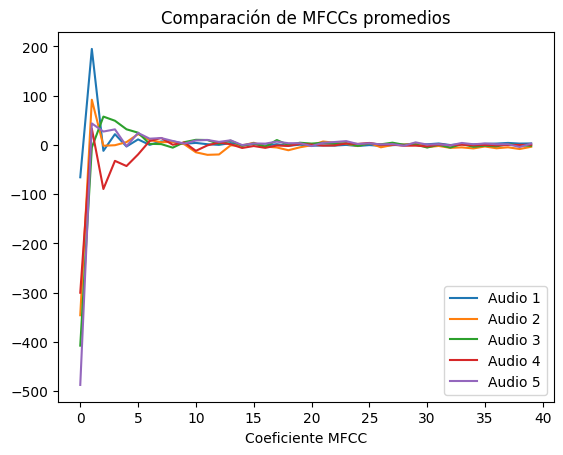

In [21]:
for i in range(5):  # Primeros 5 archivos
    plt.plot(df_real['mfcc_mean'].iloc[i], label=f'Audio {i+1}')
plt.title("Comparación de MFCCs promedios")
plt.xlabel("Coeficiente MFCC")
plt.legend()
plt.show()